## Ensembles and random forest. Part 1. Bagging

If we have choosen the best possible model for a particular problem and are struggling to improve further accuracy, then we would need to apply some more advanced machine learning techniques that are collectively referred to as ensembles.

An ensemble is a set of elements that collectively contribute to a whole. reference - musical ensemble, which blends the sounds of several musical instruments to create harmony

## Enembles
" if each member of the jury makes an independent judgement and the probability of the correct decision by each juror is more than 0.5, then the probability of the correct decision by the whole jury increases with the total number of jurors and tends to one " - which means a large group of independent, moderately competent decision-makers can collectively make very accurate decisions.

# 2. Bootstrapping

Bagging, also known as bootstrap aggregation is one of the first and most basic ensemble technique. Bagging is the statistical method of bootstrapping

```
Bootstrap aggregating, also called bagging (from bootstrap aggregating) or bootstrapping, is a machine learning (ML) ensemble meta-algorithm designed to improve the stability and accuracy of ML classification and regression algorithms. It also reduces variance and overfitting. Although it is usually applied to decision tree methods, it can be used with any type of method. Bagging is a special case of the ensemble averaging approach.
```

```
Bootstrapping is a procedure for estimating the distribution of an estimator by resampling (often with replacement) one's data or a model which is estimated from the data.[1] Bootstrapping assigns measures of accuracy (bias, variance, confidence intervals, prediction error, etc.) to sample estimates.[2][3] This technique allows estimation of the sampling distribution of almost any statistic using random sampling methods
```

In [1]:
import numpy as np
import pandas as pd

import seaborn as sns
sns.set_theme()

from matplotlib import pyplot as plt
%config InlineBackend.figure_format = 'retina'

In [2]:
DATA_PATH = "https://raw.githubusercontent.com/Yorko/mlcourse.ai/main/data/"

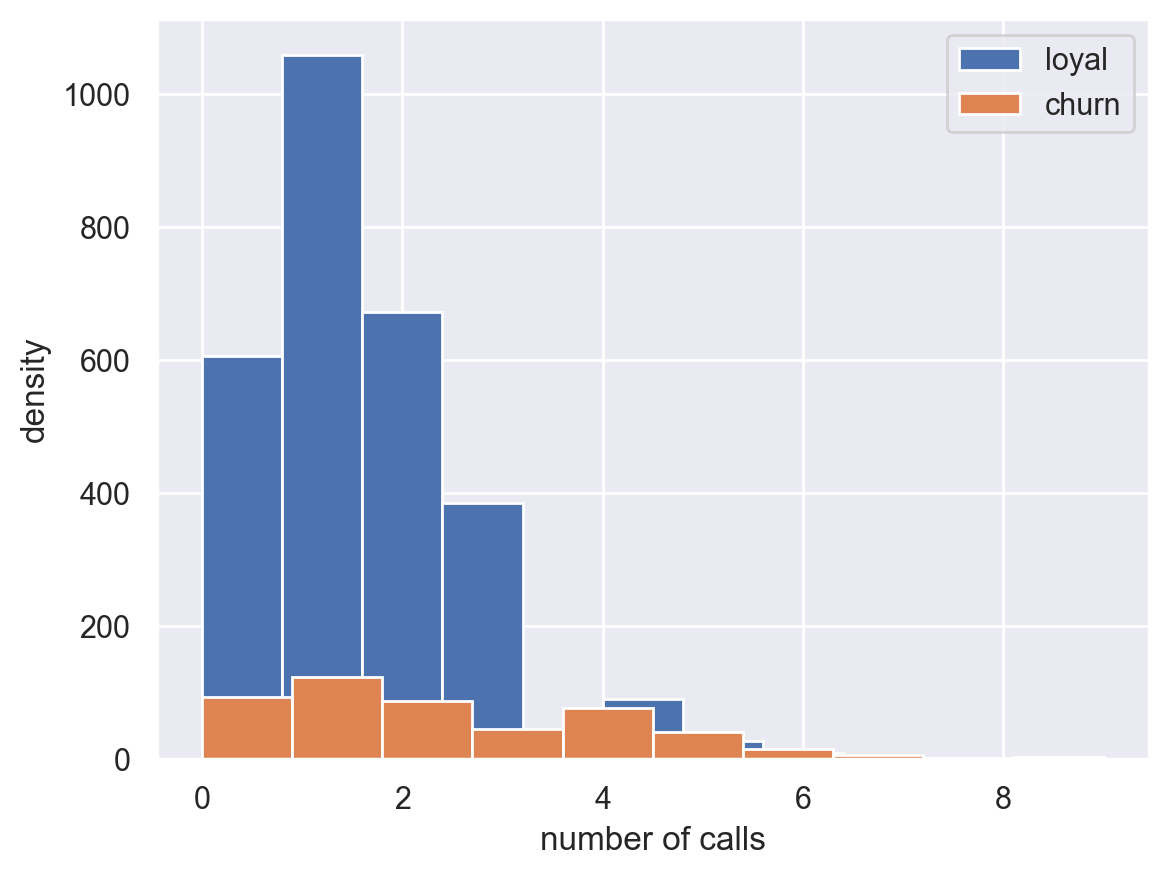

In [3]:
telecom_data = pd.read_csv(DATA_PATH + "telecom_churn.csv")
telecom_data.loc[telecom_data["Churn"] == False, "Customer service calls"].hist(label="loyal")
telecom_data.loc[telecom_data["Churn"] == True, "Customer service calls"].hist(label="churn")

plt.xlabel("number of calls")
plt.ylabel("density")
plt.legend()


In [4]:
# np.random.randint(low, high=None, size=None, dtype=int)
data = np.array([10,20,30,40,50])
indices = np.random.randint(0,5,(5,5))
sample = data[indices]
indices, sample

(array([[3, 2, 2, 4, 4],
        [3, 2, 4, 3, 3],
        [1, 4, 3, 3, 1],
        [0, 2, 2, 2, 0],
        [3, 4, 3, 1, 0]], dtype=int32),
 array([[40, 30, 30, 50, 50],
        [40, 30, 50, 40, 40],
        [20, 50, 40, 40, 20],
        [10, 30, 30, 30, 10],
        [40, 50, 40, 20, 10]]))

In [ ]:
def get_bootstrap_samples(data, n_samples):
    """ Generate bootstrap samples using bootstrap method """
    indices = np.random.randint(0, len(data), (n_samples, len(data)))
    samples = data[indices]
    return samples

def stat_intervals(stat, alpha):
    """ produce an interval estimate """
    boundaries = np.percentile(stat, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return boundaries

# save the data about the loyal and former customers to split the dataset
loyal_calls = telecom_data.loc[telecom_data["Churn"] == False, "Customer service calls"].values
churn_calls = telecom_data.loc[telecom_data["Churn"] == True, "Customer service calls"].values

# set the seed for reproducibality of the result , same as random_state
np.random.seed(0)

# Generate the samples using bootstrapping and calculate the mean for each of them
loyal_mean_scores = [
    np.mean(sample) for sample in get_bootstrap_samples(loyal_calls, 1000)
]
churn_mean_scores = [
    np.mean(sample) for sample in get_bootstrap_samples(churn_calls, 1000)
]

# Print the resulting interval estimates
print(
    "Service calls from loyal: mean interval", stat_intervals(loyal_mean_scores, 0.05)
)
print(
    "Service calls from churn: mean interval", stat_intervals(churn_mean_scores, 0.05)
)

2850
